In [ ]:
# for data processing

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re

# for data pipeline --------------------

from sklearn.model_selection import train_test_split
from sklearn.metrics import*
import matplotlib.pyplot as plt
from sklearn.model_selection import*
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# for prediction (machine learning models) ------------------------

from sklearn.linear_model import*
from sklearn.preprocessing import*
from sklearn.ensemble import*
from sklearn.neighbors import*
from sklearn import svm
from sklearn.naive_bayes import*
import xgboost as xgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read train and test dataset

train_df = pd.read_excel("/content/Final_Train.xlsx")
test_df = pd.read_excel("/content/Final_Test.xlsx")
df_test = test_df.copy()

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
train_path='/content/Final_Train.xlsx'
test_path='/content/Final_Test.xlsx'

In [ ]:
train=pd.read_excel(train_path)
test=pd.read_excel(test_path)

In [ ]:
train.head()

,Qualification,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees
0,"BHMS, MD - Homeopathy",24 years experience,100%,"Kakkanad, Ernakulam",Homeopath,"100% 16 Feedback Kakkanad, Ernakulam",100
1,"BAMS, MD - Ayurveda Medicine",12 years experience,98%,"Whitefield, Bangalore",Ayurveda,"98% 76 Feedback Whitefield, Bangalore",350
2,"MBBS, MS - Otorhinolaryngology",9 years experience,NaN,"Mathikere - BEL, Bangalore",ENT Specialist,NaN,300
3,"BSc - Zoology, BAMS",12 years experience,NaN,"Bannerghatta Road, Bangalore",Ayurveda,"Bannerghatta Road, Bangalore ₹250 Available on...",250
4,BAMS,20 years experience,100%,"Keelkattalai, Chennai",Ayurveda,"100% 4 Feedback Keelkattalai, Chennai",250


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5961 entries, 0 to 5960
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Qualification       5961 non-null   object
 1   Experience          5961 non-null   object
 2   Rating              2659 non-null   object
 3   Place               5936 non-null   object
 4   Profile             5961 non-null   object
 5   Miscellaneous_Info  3341 non-null   object
 6   Fees                5961 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 326.1+ KB


### Preprocessing

In [ ]:
for i in train['Miscellaneous_Info'].value_counts().index:
  train['Miscellaneous_Info'].replace(i,int(1),inplace=True)
train['Miscellaneous_Info'].fillna(int(0),inplace=True)

for i in test['Miscellaneous_Info'].value_counts().index:
  test['Miscellaneous_Info'].replace(i,int(1),inplace=True)
test['Miscellaneous_Info'].fillna(int(0),inplace=True)

In [ ]:
for i in train['Experience'].value_counts().index:
  ww=i.split()
  train['Experience'].replace(i,int(ww[0]),inplace=True)

for i in test['Experience'].value_counts().index:
  ww=i.split()
  test['Experience'].replace(i,int(ww[0]),inplace=True)

In [ ]:
train['Place'].fillna('None,None',inplace=True)
test['Place'].fillna('None,None',inplace=True)

In [ ]:
train['Area']=train['Place'].str.rsplit(',',1).str.get(0)
train['City']=train['Place'].str.rsplit(',',1).str.get(1)
test['Area']=test['Place'].str.rsplit(',',1).str.get(0)
test['City']=test['Place'].str.split(',',1).str.get(1)

train['City']=train['City'].str.strip()
test['City']=test['City'].str.strip()

<ipython-input-62-547c18c566dc>:1: FutureWarning: In a future version of pandas all arguments of StringMethods.rsplit except for the argument 'pat' will be keyword-only.
  train['Area']=train['Place'].str.rsplit(',',1).str.get(0)
<ipython-input-62-547c18c566dc>:2: FutureWarning: In a future version of pandas all arguments of StringMethods.rsplit except for the argument 'pat' will be keyword-only.
  train['City']=train['Place'].str.rsplit(',',1).str.get(1)
<ipython-input-62-547c18c566dc>:3: FutureWarning: In a future version of pandas all arguments of StringMethods.rsplit except for the argument 'pat' will be keyword-only.
  test['Area']=test['Place'].str.rsplit(',',1).str.get(0)
<ipython-input-62-547c18c566dc>:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  test['City']=test['Place'].str.split(',',1).str.get(1)


In [ ]:
train['Area'].isnull().sum(),test['Area'].isnull().sum(),train['City'].isnull().sum(),test['City'].isnull().sum()

(0, 0, 1, 0)

In [ ]:
train[train['City'].isnull()]

,Qualification,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees,Area,City
3980,BDS,23,NaN,e,Dentist,0.0,250,e,NaN


In [ ]:
train.loc[train['City'].isnull(),'Area']='None'
train['City']=train['City'].fillna('None')

In [ ]:
train['Area'].isnull().sum(),test['Area'].isnull().sum(),train['City'].isnull().sum(),test['City'].isnull().sum()

(0, 0, 0, 0)

In [ ]:
train['Qualification'].value_counts()[:30]

BDS                                                      488
BHMS                                                     477
BAMS                                                     471
MBBS                                                     334
MBBS, MS - ENT                                           220
MBBS, MD - Dermatology                                   178
MBBS, MD - General Medicine                              177
MBBS, MD - Dermatology , Venereology & Leprosy           140
BHMS, MD - Homeopathy                                     93
MBBS, DDVL                                                92
MBBS, Diploma in Otorhinolaryngology (DLO)                84
BAMS, MD - Ayurveda Medicine                              82
BDS, MDS - Conservative Dentistry & Endodontics           68
MBBS, DDV                                                 66
BDS, MDS                                                  63
BDS, MDS - Oral & Maxillofacial Surgery                   57
MD - Dermatology , Vener

In [ ]:
# func to make feature
def fun(arr,string):
  for data in dat:
    if data.find(string) !=-1:
      arr.append(int(1))
    else :
      arr.append(int(0))
def to_df(lst):
  lst=pd.DataFrame(lst)
  return lst

cols=['mbbs','bhms','bams','ddvl','dlo','mlo','dnb','bds','md','ms','fellowship']

In [ ]:
dat=train['Qualification']

mbbs=[]
bds=[]
bams=[]
md=[]
bhms=[]
fellowship=[]
dlo=[]
mlo=[]
dnb=[]
ddvl=[]
ms=[]

fun(mbbs,'MBBS')
fun(bds,'BDS')
fun(bams,'BAMS')
fun(md,'MD')
fun(bhms,'BHMS')
fun(fellowship,'Fellowship')
fun(dlo,'DLO')
fun(mlo,'MLO')
fun(dnb,'DNB')
fun(ddvl,'DDVL')
fun(ms,'MS')

mbbs=to_df(mbbs)
bds=to_df(bds)
bams=to_df(bams)
md=to_df(md)
bhms=to_df(bhms)
fellowship=to_df(fellowship)
dlo=to_df(dlo)
mlo=to_df(mlo)
dnb=to_df(dnb)
ddvl=to_df(ddvl)
ms=to_df(ms)

train.drop('Qualification',1,inplace=True)
train=pd.concat([mbbs,bhms,bams,ddvl,dlo,mlo,dnb,bds,md,ms,fellowship,train],axis=1)

mx=train.columns[11:]
for i in mx:
  cols.append(i)
train.columns=cols
train.head()

<ipython-input-69-10fd108f480f>:39: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  train.drop('Qualification',1,inplace=True)


,mbbs,bhms,bams,ddvl,dlo,mlo,dnb,bds,md,ms,fellowship,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees,Area,City
0,0,1,0,0,0,0,0,0,1,1,0,24,100%,"Kakkanad, Ernakulam",Homeopath,1.0,100,Kakkanad,Ernakulam
1,0,0,1,0,0,0,0,0,1,1,0,12,98%,"Whitefield, Bangalore",Ayurveda,1.0,350,Whitefield,Bangalore
2,1,0,0,0,0,0,0,0,0,1,0,9,NaN,"Mathikere - BEL, Bangalore",ENT Specialist,0.0,300,Mathikere - BEL,Bangalore
3,0,0,1,0,0,0,0,0,0,1,0,12,NaN,"Bannerghatta Road, Bangalore",Ayurveda,1.0,250,Bannerghatta Road,Bangalore
4,0,0,1,0,0,0,0,0,0,1,0,20,100%,"Keelkattalai, Chennai",Ayurveda,1.0,250,Keelkattalai,Chennai


In [ ]:
dat=test['Qualification']
mbbs=[]
bds=[]
bams=[]
md=[]
bhms=[]
fellowship=[]
dlo=[]
mlo=[]
dnb=[]
ddvl=[]
ms=[]

dat=test['Qualification']
fun(mbbs,'MBBS')
fun(bds,'BDS')
fun(bams,'BAMS')
fun(md,'MD')
fun(bhms,'BHMS')
fun(fellowship,'Fellowship')
fun(dlo,'DLO')
fun(mlo,'MLO')
fun(dnb,'DNB')
fun(ddvl,'DDVL')
fun(ms,'MS')

mbbs=to_df(mbbs)
bds=to_df(bds)
bams=to_df(bams)
md=to_df(md)
bhms=to_df(bhms)
fellowship=to_df(fellowship)
dlo=to_df(dlo)
mlo=to_df(mlo)
dnb=to_df(dnb)
ddvl=to_df(ddvl)
ms=to_df(ms)

test.drop('Qualification',1,inplace=True)
test=pd.concat([mbbs,bhms,bams,ddvl,dlo,mlo,dnb,bds,md,ms,fellowship,test],axis=1)

cols=['mbbs','bhms','bams','ddvl','dlo','mlo','dnb','bds','md','ms','fellowship']
mx=test.columns[11:]
for i in mx:
  cols.append(i)

test.columns=cols
test.head()

<ipython-input-70-e871aee038ba>:39: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  test.drop('Qualification',1,inplace=True)


,mbbs,bhms,bams,ddvl,dlo,mlo,dnb,bds,md,ms,fellowship,Experience,Rating,Place,Profile,Miscellaneous_Info,Area,City
0,1,0,0,0,0,0,0,0,0,0,0,35,NaN,"Ghatkopar East, Mumbai",General Medicine,0.0,Ghatkopar East,Mumbai
1,1,0,0,0,1,0,0,0,0,0,0,31,NaN,"West Marredpally, Hyderabad",ENT Specialist,0.0,West Marredpally,Hyderabad
2,1,0,0,1,0,0,0,0,0,0,0,40,70%,"KK Nagar, Chennai",Dermatologists,1.0,KK Nagar,Chennai
3,0,0,1,0,0,0,0,0,0,1,0,0,NaN,"New Ashok Nagar, Delhi",Ayurveda,0.0,New Ashok Nagar,Delhi
4,0,0,0,0,0,0,0,1,1,0,0,16,100%,"Kanakpura Road, Bangalore",Dentist,1.0,Kanakpura Road,Bangalore


In [ ]:
train['Rating'].fillna('-99999%',inplace=True)
test['Rating'].fillna('-99999%',inplace=True)

for i in train['Rating'].value_counts().index:
  train['Rating'].replace(i,int(i[:-1]),inplace=True)

for i in test['Rating'].value_counts().index:
  test['Rating'].replace(i,int(i[:-1]),inplace=True)

In [ ]:
train.head()

,mbbs,bhms,bams,ddvl,dlo,mlo,dnb,bds,md,ms,fellowship,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees,Area,City
0,0,1,0,0,0,0,0,0,1,1,0,24,100,"Kakkanad, Ernakulam",Homeopath,1.0,100,Kakkanad,Ernakulam
1,0,0,1,0,0,0,0,0,1,1,0,12,98,"Whitefield, Bangalore",Ayurveda,1.0,350,Whitefield,Bangalore
2,1,0,0,0,0,0,0,0,0,1,0,9,-99999,"Mathikere - BEL, Bangalore",ENT Specialist,0.0,300,Mathikere - BEL,Bangalore
3,0,0,1,0,0,0,0,0,0,1,0,12,-99999,"Bannerghatta Road, Bangalore",Ayurveda,1.0,250,Bannerghatta Road,Bangalore
4,0,0,1,0,0,0,0,0,0,1,0,20,100,"Keelkattalai, Chennai",Ayurveda,1.0,250,Keelkattalai,Chennai


# performing EDA

In [ ]:
profile=train['Profile'].value_counts().index
Area=train['Area'].value_counts().index
City=train['City'].value_counts().index

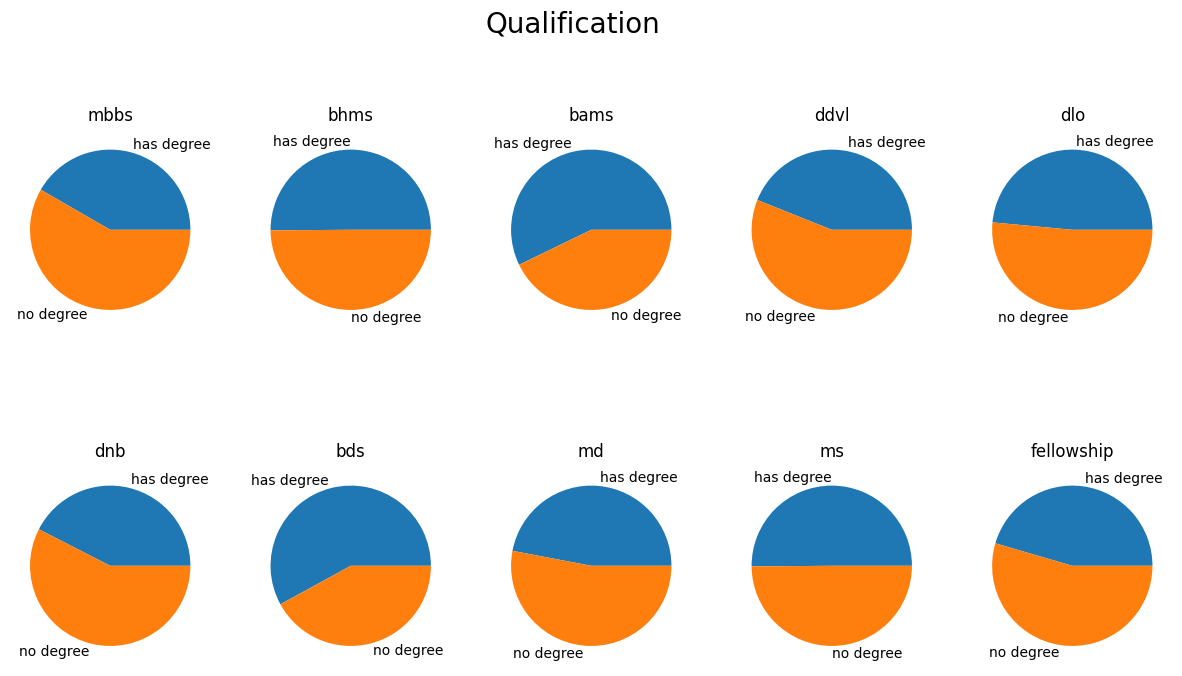

In [ ]:
col1=['mbbs','bhms','bams','ddvl','dlo','dnb','bds','md','ms','fellowship']
lab=['has degree','no degree']
fig,axes=plt.subplots(2,5,figsize=(15,8))
fig.suptitle('Qualification',fontsize=20)
k=1
for col in col1:
  arr=[]
  for i in range(2):
    x=train[train[col]==i]
    arr.append(np.mean(x['Fees']))
  plt.subplot(2,5,k)
  k+=1
  plt.title(col)
  plt.pie(arr,labels=lab)
plt.show()

In [ ]:
col2=['mbbs','bhms','bams','ddvl','dlo','mlo','dnb','bds','md','ms','fellowship']
summ=np.zeros(len(train))
for i in col2:
  arr=train[i]
  summ=np.add(summ,arr)
temp_df=pd.DataFrame({'qual':summ,'fees':train['Fees']})     # created a dataframe adding all the qualifications into one.

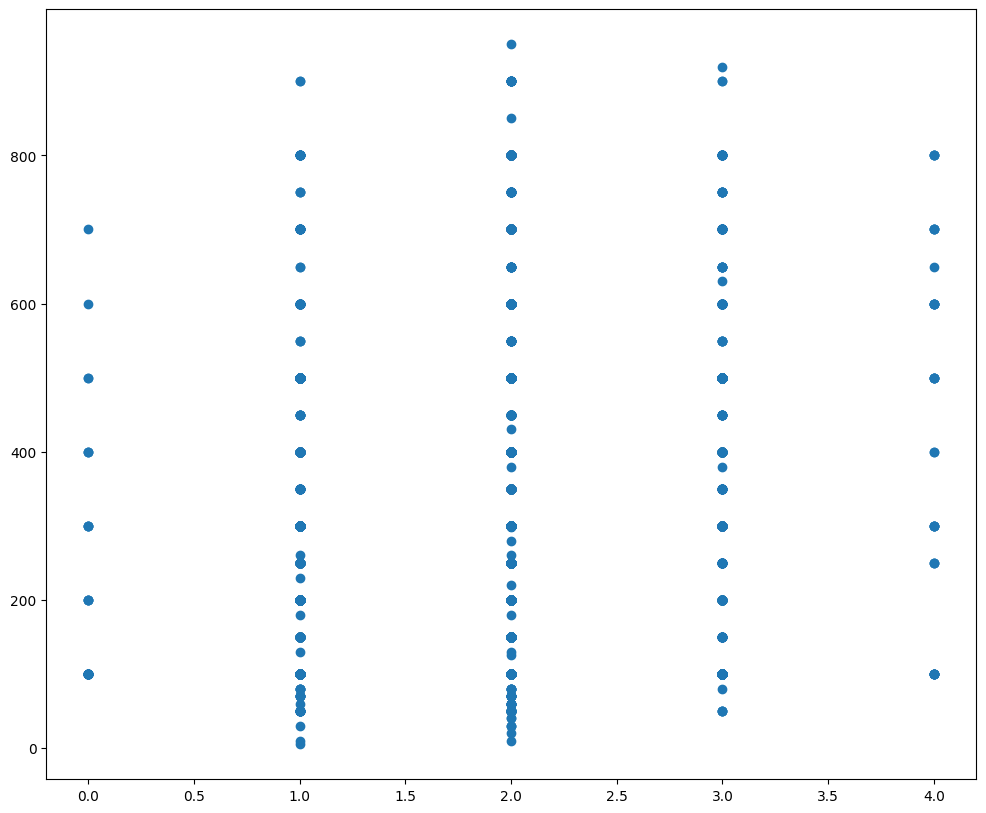

In [ ]:
plt.scatter(temp_df['qual'],temp_df['fees'])

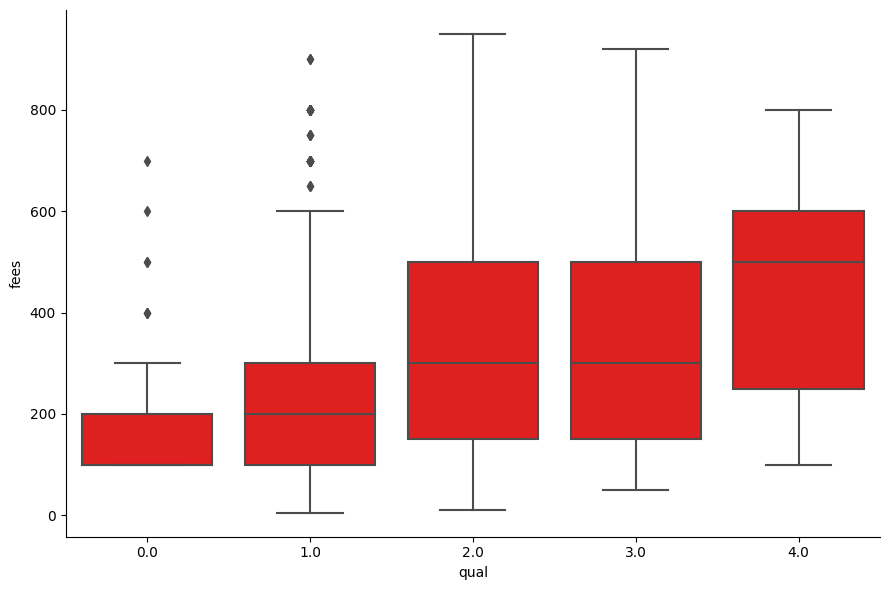

In [ ]:
sns.catplot(x='qual',y='fees', data=temp_df.sort_values("fees"),kind='box',height=6,aspect= 1.5,color='r')
plt.show()

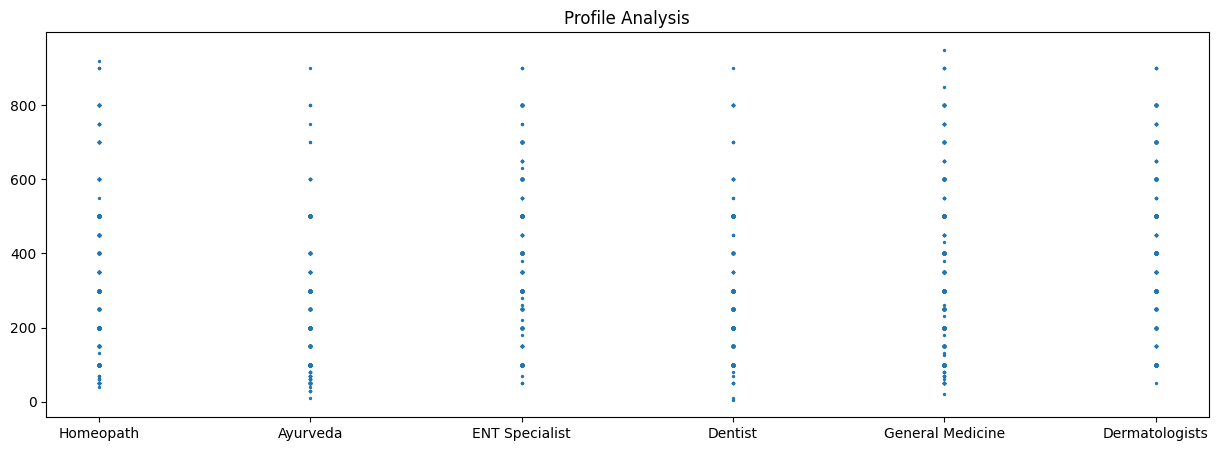

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Profile Analysis')

plt.scatter(train['Profile'],train['Fees'],s=2)
plt.show()

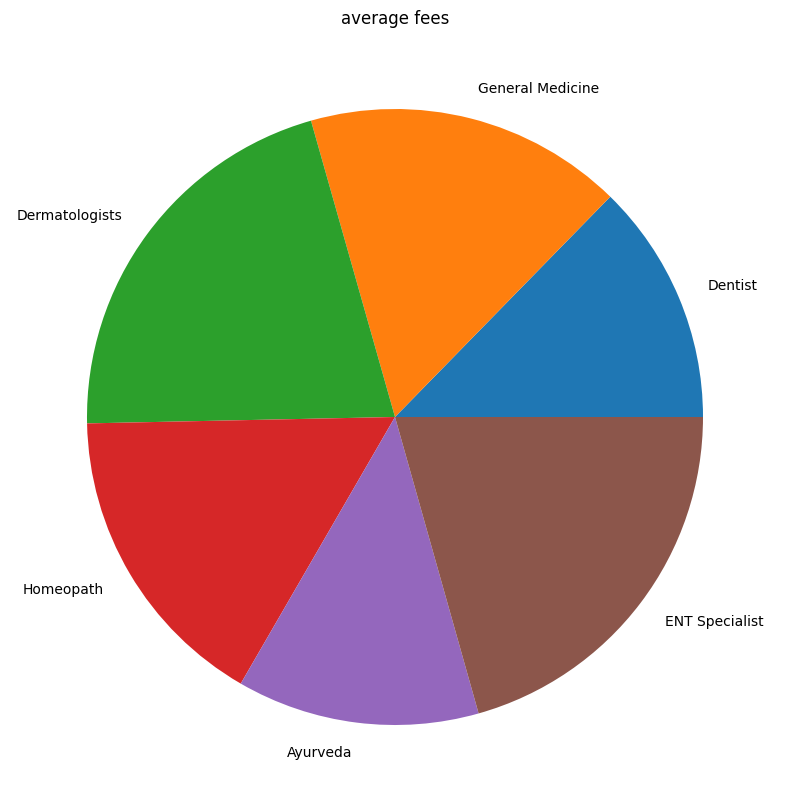

In [ ]:
arr=[]
for i in profile:
  x=train[train['Profile']==i]
  arr.append(np.mean(x['Fees']))
plt.title('average fees')
plt.pie(arr,labels=profile)
plt.show()

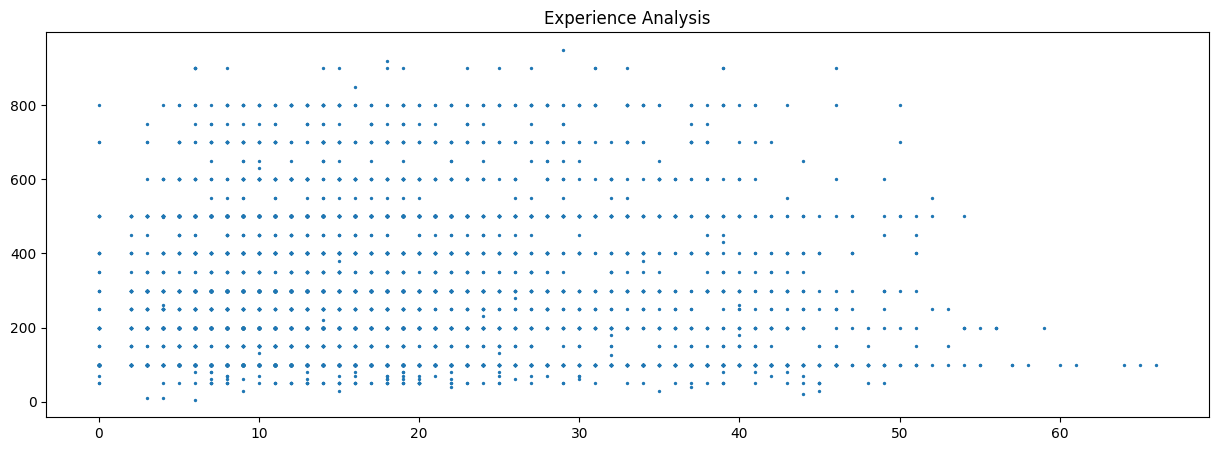

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Experience Analysis')

plt.scatter(train['Experience'],train['Fees'],s=2)
plt.show()

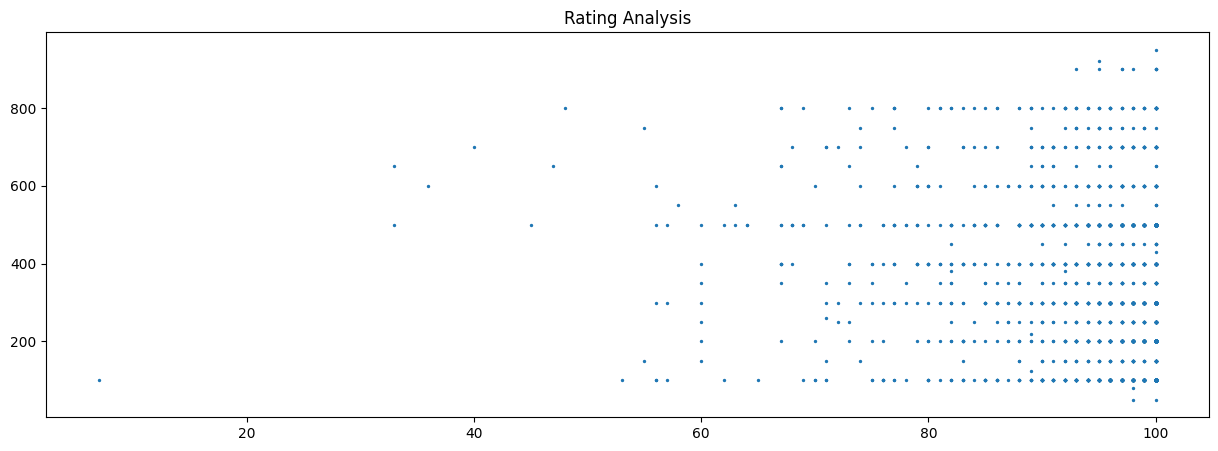

In [ ]:
xx=train[train['Rating']>=0.0]
plt.figure(figsize=(15,5))
plt.title('Rating Analysis')

plt.scatter(xx['Rating'],xx['Fees'],s=2)
plt.show()

###Final Pre-processing

In [ ]:
train.drop(labels=col2,axis=1,inplace=True)
qual=temp_df['qual']                                         # for train data
qual=to_df(qual)
train=pd.concat([qual,train],axis=1)
train.head()

,qual,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees,Area,City
0,3.0,24,100,"Kakkanad, Ernakulam",Homeopath,1.0,100,Kakkanad,Ernakulam
1,3.0,12,98,"Whitefield, Bangalore",Ayurveda,1.0,350,Whitefield,Bangalore
2,2.0,9,-99999,"Mathikere - BEL, Bangalore",ENT Specialist,0.0,300,Mathikere - BEL,Bangalore
3,2.0,12,-99999,"Bannerghatta Road, Bangalore",Ayurveda,1.0,250,Bannerghatta Road,Bangalore
4,2.0,20,100,"Keelkattalai, Chennai",Ayurveda,1.0,250,Keelkattalai,Chennai


In [ ]:
summ=np.zeros(len(test))
for i in col2:
  arr=test[i]
  summ=np.add(summ,arr)
temp_df=pd.DataFrame({'qual':summ})
test.drop(labels=col2,axis=1,inplace=True)
test=pd.concat([temp_df,test],axis=1)
test.head()

,qual,Experience,Rating,Place,Profile,Miscellaneous_Info,Area,City
0,1.0,35,-99999,"Ghatkopar East, Mumbai",General Medicine,0.0,Ghatkopar East,Mumbai
1,2.0,31,-99999,"West Marredpally, Hyderabad",ENT Specialist,0.0,West Marredpally,Hyderabad
2,2.0,40,70,"KK Nagar, Chennai",Dermatologists,1.0,KK Nagar,Chennai
3,2.0,0,-99999,"New Ashok Nagar, Delhi",Ayurveda,0.0,New Ashok Nagar,Delhi
4,2.0,16,100,"Kanakpura Road, Bangalore",Dentist,1.0,Kanakpura Road,Bangalore


In [ ]:
def encode(str):
  scaler=LabelEncoder()
  ar1=train[str]
  ar1=scaler.fit_transform(ar1)
  train[str]=ar1
  ar2=test[str]
  ar2=scaler.transform(ar2)
  test[str]=ar2

In [ ]:
encode('Profile')
encode('City')

In [ ]:
x1=train['Area']
x2=test['Area']
try:
  encode('Area')
except:
  print('ERROR ! New area token found in test.')
  train['Area']=x1
  test['Area']=x2

ERROR ! New area token found in test.


In [ ]:
xx=train['Area'].value_counts().index
xy=test['Area'].value_counts().index
xx=to_df(xx)
xy=to_df(xy)

In [ ]:
x3=pd.concat([xx,xy],axis=0)
x3.columns=['0']
a1=x3['0'].value_counts().index
i=0
for val in a1:
  train['Area'].replace(val,int(i),inplace=True)
  test['Area'].replace(val,int(i),inplace=True)
  i+=1

In [ ]:
X_train=train.drop('Fees',1)
y_train=train['Fees']
X_test=test

<ipython-input-89-65d9f320b220>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  X_train=train.drop('Fees',1)


In [ ]:
print('shape of the X and Y s')
X_train.shape,y_train.shape,X_test.shape

shape of the X and Y s


((5961, 8), (5961,), (1987, 8))

In [ ]:
print(X_train.info())
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5961 entries, 0 to 5960
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   qual                5961 non-null   float64
 1   Experience          5961 non-null   int64  
 2   Rating              5961 non-null   int64  
 3   Place               5961 non-null   object 
 4   Profile             5961 non-null   int64  
 5   Miscellaneous_Info  5961 non-null   float64
 6   Area                5961 non-null   int64  
 7   City                5961 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 372.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   qual                1987 non-null   float64
 1   Experience          1987 non-null   int64  
 2   Rating              1987 non

In [ ]:
clf=RandomForestRegressor(random_state=0,criterion='squared_error')
X_tr = X_train.drop(['Place'],1)
clf.fit(X_tr,y_train)
y_pred=clf.predict(X_tr)
print('RMSE loss in train :',np.sqrt(mean_squared_error(y_train,y_pred)))

<ipython-input-103-e5084127329d>:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  X_tr = X_train.drop(['Place'],1)


RMSE loss in train : 64.20386844298703


In [ ]:
clf.score(X_tr,y_train)

0.8868926817568528

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming X_tr and y_train are your training data
# Drop the 'Place' column as you did for RandomForestRegressor
X_tr = X_train.drop(['Place'], axis=1)

# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_tr, y_train)
y_pred_linear = linear_reg.predict(X_tr)
rmse_linear = np.sqrt(mean_squared_error(y_train, y_pred_linear))

# # Support Vector Regression (SVR)
# svr = SVR()
# svr.fit(X_tr, y_train)
# y_pred_svr = svr.predict(X_tr)
# rmse_svr = np.sqrt(mean_squared_error(y_train, y_pred_svr))

# Gradient Boosting Regressor
gb_regressor = GradientBoostingRegressor(random_state=0)
gb_regressor.fit(X_tr, y_train)
y_pred_gb = gb_regressor.predict(X_tr)
rmse_gb = np.sqrt(mean_squared_error(y_train, y_pred_gb))

# RandomForestRegressor (as you mentioned)
clf = RandomForestRegressor(random_state=0, criterion='squared_error')
clf.fit(X_tr, y_train)
y_pred_rf = clf.predict(X_tr)
rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf))

# Display RMSE for each model
print(f'Linear Regression RMSE: {rmse_linear:.4f}')
# print(f'SVR RMSE: {rmse_svr:.4f}')
print(f'Gradient Boosting RMSE: {rmse_gb:.4f}')
print(f'Random Forest RMSE: {rmse_rf:.4f}')


Linear Regression RMSE: 182.3254
Gradient Boosting RMSE: 162.6172
Random Forest RMSE: 64.2039


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming X_tr and y_train are your training data
# Drop the 'Place' column as you did for RandomForestRegressor
X_tr = X_train.drop(['Place'], axis=1)

# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_tr, y_train)
r2_linear = linear_reg.score(X_tr, y_train)

# # Support Vector Regression (SVR)
# svr = SVR()
# svr.fit(X_tr, y_train)
# r2_svr = svr.score(X_tr, y_train)

# Gradient Boosting Regressor
gb_regressor = GradientBoostingRegressor(random_state=0)
gb_regressor.fit(X_tr, y_train)
r2_gb = gb_regressor.score(X_tr, y_train)

# RandomForestRegressor (as you mentioned)
clf = RandomForestRegressor(random_state=0, criterion='squared_error')
clf.fit(X_tr, y_train)
r2_rf = clf.score(X_tr, y_train)

# Display R-squared for each model
print(f'Linear Regression R-squared: {r2_linear:.4f}')
# print(f'SVR R-squared: {r2_svr:.4f}')
print(f'Gradient Boosting R-squared: {r2_gb:.4f}')
print(f'Random Forest R-squared: {r2_rf:.4f}')


Linear Regression R-squared: 0.0879
Gradient Boosting R-squared: 0.2744
Random Forest R-squared: 0.8869


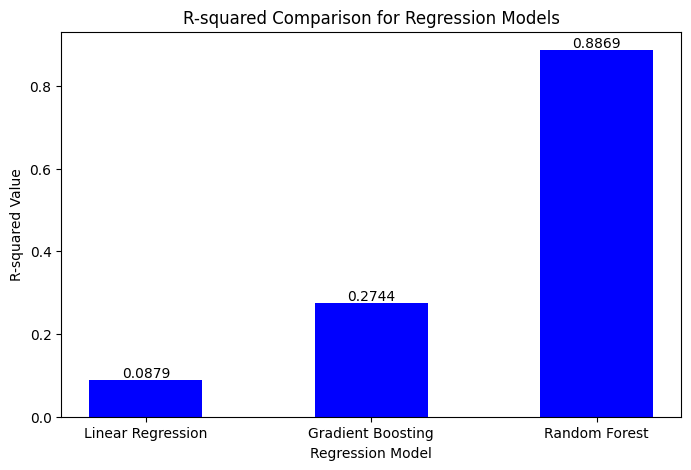

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming r2 values are the R-squared values for each model
models = ['Linear Regression', 'Gradient Boosting', 'Random Forest']
r2_values = [0.0879, 0.2744, 0.8869]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Bar width
bar_width = 0.5

# Positions of bars on X-axis
index = np.arange(len(models))

# Plot R-squared values
bars = ax.bar(index, r2_values, bar_width, color='blue')

# Set labels, title, and legend
ax.set_xlabel('Regression Model')
ax.set_ylabel('R-squared Value')
ax.set_title('R-squared Comparison for Regression Models')
ax.set_xticks(index)
ax.set_xticklabels(models)

# Display the values on top of the bars
for bar, value in zip(bars, r2_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{value:.4f}', ha='center', va='bottom')

plt.show()


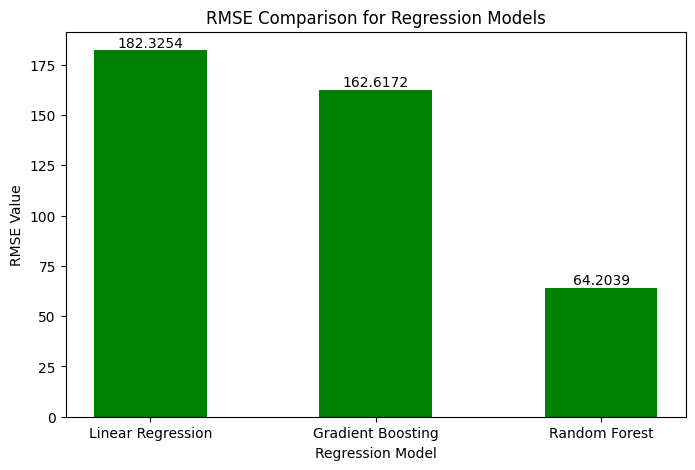

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming RMSE values are the root mean squared error values for each model
models = ['Linear Regression', 'Gradient Boosting', 'Random Forest']
rmse_values = [182.3254, 162.6172, 64.2039]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Bar width
bar_width = 0.5

# Positions of bars on X-axis
index = np.arange(len(models))

# Plot RMSE values
bars = ax.bar(index, rmse_values, bar_width, color='green')

# Set labels, title, and legend
ax.set_xlabel('Regression Model')
ax.set_ylabel('RMSE Value')
ax.set_title('RMSE Comparison for Regression Models')
ax.set_xticks(index)
ax.set_xticklabels(models)

# Display the values on top of the bars
for bar, value in zip(bars, rmse_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{value:.4f}', ha='center', va='bottom')

plt.show()
